In [2]:
import matplotlib.pyplot as plt
import numpy as np
import src.util as util

from src.linear_model import LinearModel

In [3]:
x_train, y_train = util.load_dataset('data/ds3_train.csv', add_intercept=True)
_, t_train = util.load_dataset('data/ds3_train.csv', label_col='t')
x_valid, y_valid = util.load_dataset('data/ds3_valid.csv', add_intercept=True)
_, t_valid = util.load_dataset('data/ds3_valid.csv', label_col='t')
x_test, y_test = util.load_dataset('data/ds3_test.csv', add_intercept=True)
_, t_test = util.load_dataset('data/ds3_test.csv', label_col='t')

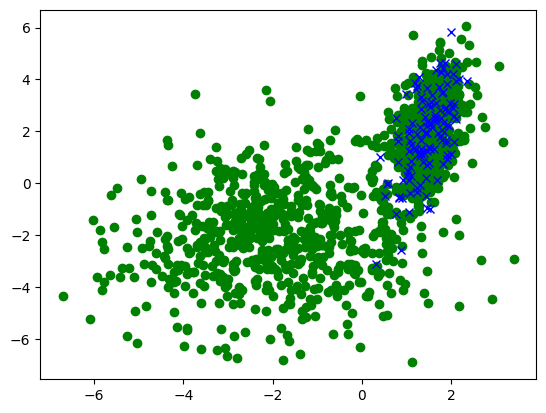

In [4]:
plt.figure()
plt.plot(x_train[y_train == 0, -2], x_train[y_train == 0, -1], 'go', linewidth=2)
plt.plot(x_train[y_train == 1, -2], x_train[y_train == 1, -1], 'bx', linewidth=2)

In [5]:
class LogisticRegression(LinearModel):
    """Logistic regression with Newton's Method as the solver.

    Example usage:
        > clf = LogisticRegression()
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """

    def fit(self, x, y):
        """Run Newton's Method to minimize J(theta) for logistic regression.

        Args:
            x: Training example inputs. Shape (m, n).
            y: Training example labels. Shape (m,).
        """
        # *** START CODE HERE ***
        
        def h(theta, x):
            """
            x: (m, n)
            return (m, )
            """
            return 1 / (1+np.exp(-(x @ theta)))
        
        def gradient(theta, x, y):
            m, _ = x.shape
            return -1/m * x.T @ (y-h(theta, x))
        
        def hessian(theta, x):
            """
            (n,m) x (m, ) * 
            """
            m, _ = x.shape
            return 1/m * x.T @ np.diag(h(theta, x) * (1-h(theta,x))) @ x
            
        m,n = x.shape
        if self.theta is None:
            self.theta = np.zeros(n)
        self.theta = self.theta - np.linalg.inv(hessian(self.theta, x)) @ gradient(self.theta, x, y)
        # *** END CODE HERE ***

    def predict(self, x):
        """Make a prediction given new inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        # *** START CODE HERE ***
        # *** END CODE HERE ***
        return x @ self.theta >= 0

#### (c)

In [6]:
log_reg = LogisticRegression()

Theta =  [-0.9711418   2.73208784  1.07403478]
Accuracy is 0.9632


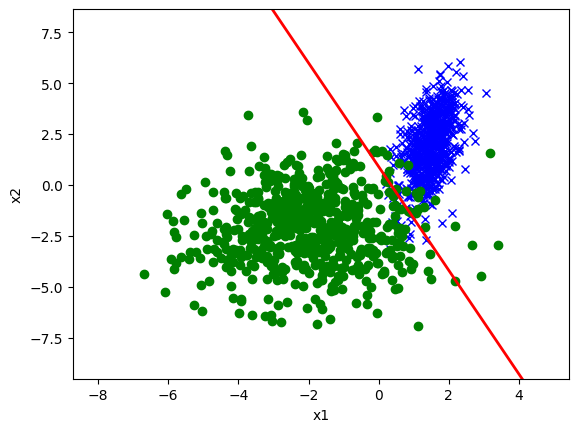

In [7]:
for i in range(100):
    log_reg.fit(x_train, t_train)
util.plot(x_train, t_train, log_reg.theta)
print("Theta = ", log_reg.theta)
print("Accuracy is", np.mean(log_reg.predict(x_train)==t_train))

Theta =  [-0.9711418   2.73208784  1.07403478]
Accuracy is 0.9596774193548387


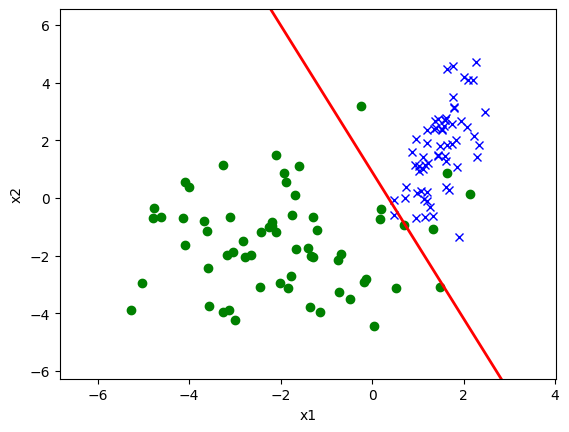

In [8]:
util.plot(x_valid, t_valid, log_reg.theta)
print("Theta = ", log_reg.theta)
print("Accuracy is", np.mean(log_reg.predict(x_valid)==t_valid))

#### (d)

In [9]:
log_reg = LogisticRegression()

Theta =  [-2.91607454  0.78596651  0.09282768]
Accuracy is 0.8870967741935484


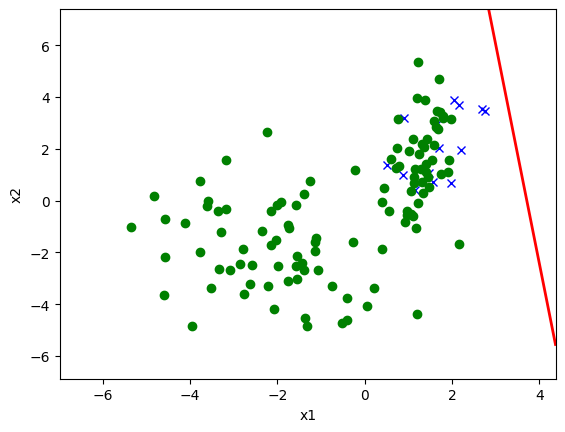

In [10]:
for i in range(100):
    log_reg.fit(x_train, y_train)
util.plot(x_test, y_test, log_reg.theta)
print("Theta = ", log_reg.theta)
print("Accuracy is", np.mean(log_reg.predict(x_test)==y_test))

Theta =  [-2.91607454  0.78596651  0.09282768]
Accuracy is 0.9032258064516129


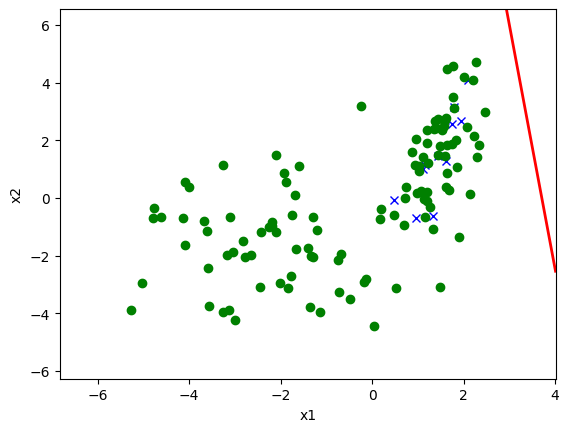

In [11]:
util.plot(x_valid, y_valid, log_reg.theta)
print("Theta = ", log_reg.theta)
print("Accuracy is", np.mean(log_reg.predict(x_valid)==y_valid))

#### (e)

In [12]:
def h(theta, x):
    """
    x: (m, n)
    return (m, )
    """
    return 1 / (1+np.exp(-(x @ theta)))
a = np.sum(h(log_reg.theta, x_valid) * y_valid) / np.sum(y_valid)
print(a)

0.17174527144749677


In [13]:
def predict(theta, x):
    return h(theta, x) / a >= 0.5

theta_prime = log_reg.theta + np.log(2/a-1) * np.array([1,0,0])


Theta =  [-0.55096984  0.78596651  0.09282768]
Accuracy is 0.31451612903225806


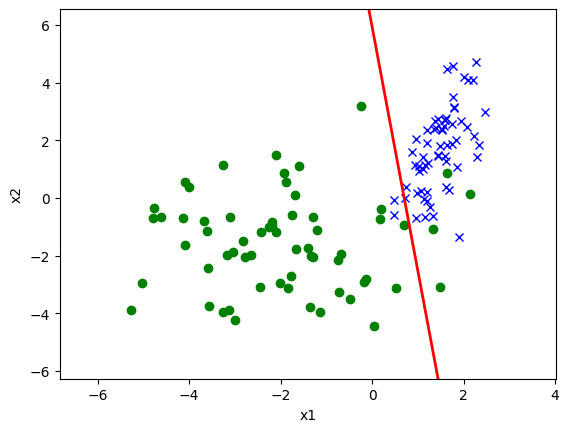

In [14]:
util.plot(x_valid, t_valid, theta_prime)
print("Theta = ", theta_prime)
print("Accuracy is", np.mean(predict(theta_prime, x_valid)==y_valid))

In [15]:
x_train, y_train = util.load_dataset('data/ds4_train.csv', add_intercept=True)
x_valid, y_valid = util.load_dataset('data/ds4_valid.csv', add_intercept=True)

AttributeError: Line2D.set() got an unexpected keyword argument 'line_width'

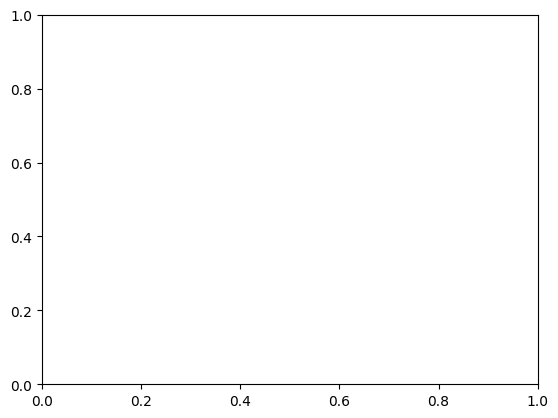

In [ ]:
plt.figure()
plt.plot(x_train[:, -2], y_train, 'o', markersize = 1)